##**[9주차]과제**
- 아래의 과제 코드를 완성하시오.
- 모든 코드의 결과를 출력하여, .ipynb의 링크를 **[9주차]/[9주차]과제**에 제출하시오.\
(실습 제출 예시: 9주차_2020XXXX_이름.ipynb 코드 링크)

# **[과제 1]** 날씨데이터를 LSTM으로 처리하는 프로그램 작성
- 아래의 baseline 모델 구조와 동일하게 모델의 구조를 정의하고,model.summary() 출력
- 정의한 모델의 학습 결과 그래프 출력, test 결과 그래프 출력


### **조건** :
1. epoch 수는 10, batch_size는 256로 고정
2. LSTM 함수 안의 파라미터를 조정하여 표기되어있는 baseline 구조와 동일하게 모델 구축
4. Dense layer의 출력 채널은 1로 설정

    예시) layer추가
```python
# 입력 SimpleRNN layer 함수 예시
keras.layers.LSTM(32)(inputs)(input)
# output layer 함수 예시
output_layer = Dense(output_channel)(input)






baseline 구조 \
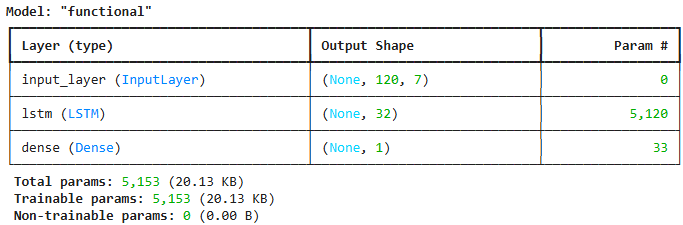

In [ ]:
print("최대영", "2353881")

최대영 2353881


In [ ]:
from google.colab import auth

auth.authenticate_user()
!gcloud config get-value account

tigers7101@gmail.com


In [ ]:
from google.colab import drive
drive.mount('/gdrive', force_remount=True)

Mounted at /gdrive


In [ ]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import pandas as pd

from zipfile import ZipFile

In [ ]:
# gpu 확인
!nvidia-smi

Wed Apr 29 02:36:38 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   68C    P0             31W /   70W |     259MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

##**데이터 불러오기**

In [ ]:
uri = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"

In [ ]:
zip_path = keras.utils.get_file(origin=uri, fname="jena_climate_2009_2016.csv.zip")
zip_file = ZipFile(zip_path)
zip_file.extractall()
csv_path = "jena_climate_2009_2016.csv"

In [ ]:
df = pd.read_csv(csv_path)

## **데이터 정제**

In [ ]:
titles = [
    "Pressure",
    "Temperature",
    "Temperature in Kelvin",
    "Temperature (dew point)",
    "Relative Humidity",
    "Saturation vapor pressure",
    "Vapor pressure",
    "Vapor pressure deficit",
    "Specific humidity",
    "Water vapor concentration",
    "Airtight",
    "Wind speed",
    "Maximum wind speed",
    "Wind direction in degrees",
]

In [ ]:
print(df.head())

             Date Time  p (mbar)  T (degC)  Tpot (K)  Tdew (degC)  rh (%)  \
0  01.01.2009 00:10:00    996.52     -8.02    265.40        -8.90    93.3   
1  01.01.2009 00:20:00    996.57     -8.41    265.01        -9.28    93.4   
2  01.01.2009 00:30:00    996.53     -8.51    264.91        -9.31    93.9   
3  01.01.2009 00:40:00    996.51     -8.31    265.12        -9.07    94.2   
4  01.01.2009 00:50:00    996.51     -8.27    265.15        -9.04    94.1   

   VPmax (mbar)  VPact (mbar)  VPdef (mbar)  sh (g/kg)  H2OC (mmol/mol)  \
0          3.33          3.11          0.22       1.94             3.12   
1          3.23          3.02          0.21       1.89             3.03   
2          3.21          3.01          0.20       1.88             3.02   
3          3.26          3.07          0.19       1.92             3.08   
4          3.27          3.08          0.19       1.92             3.09   

   rho (g/m**3)  wv (m/s)  max. wv (m/s)  wd (deg)  
0       1307.75      1.03        

In [ ]:
#DataFrame의 DataTime이후 열 이름 작성 (총 14개)
# 코드를 작성해주세요.
feature_keys = [
    "p (mbar)",
    "T (degC)",
    "Tpot (K)",
    "Tdew (degC)",
    "rh (%)",
    "VPmax (mbar)",
    "VPact (mbar)",
    "VPdef (mbar)",
    "sh (g/kg)",
    "H2OC (mmol/mol)",
    "rho (g/m**3)",
    "wv (m/s)",
    "max. wv (m/s)",
    "wd (deg)",

]

In [ ]:
colors = [
    "blue",
    "orange",
    "green",
    "red",
    "purple",
    "brown",
    "pink",
    "gray",
    "olive",
    "cyan",
]

In [ ]:
date_time_key = "Date Time"

In [ ]:
def show_raw_visualization(data):
    time_data = data[date_time_key]
    fig, axes = plt.subplots(
        nrows=7, ncols=2, figsize=(15, 20), dpi=80, facecolor="w", edgecolor="k"
    )
    for i in range(len(feature_keys)):
        key = feature_keys[i]
        c = colors[i % (len(colors))]
        t_data = data[key]
        t_data.index = time_data
        t_data.head()
        ax = t_data.plot(
            ax=axes[i // 2, i % 2],
            color=c,
            title="{} - {}".format(titles[i], key),
            rot=25,
        )
        ax.legend([titles[i]])
    plt.tight_layout()

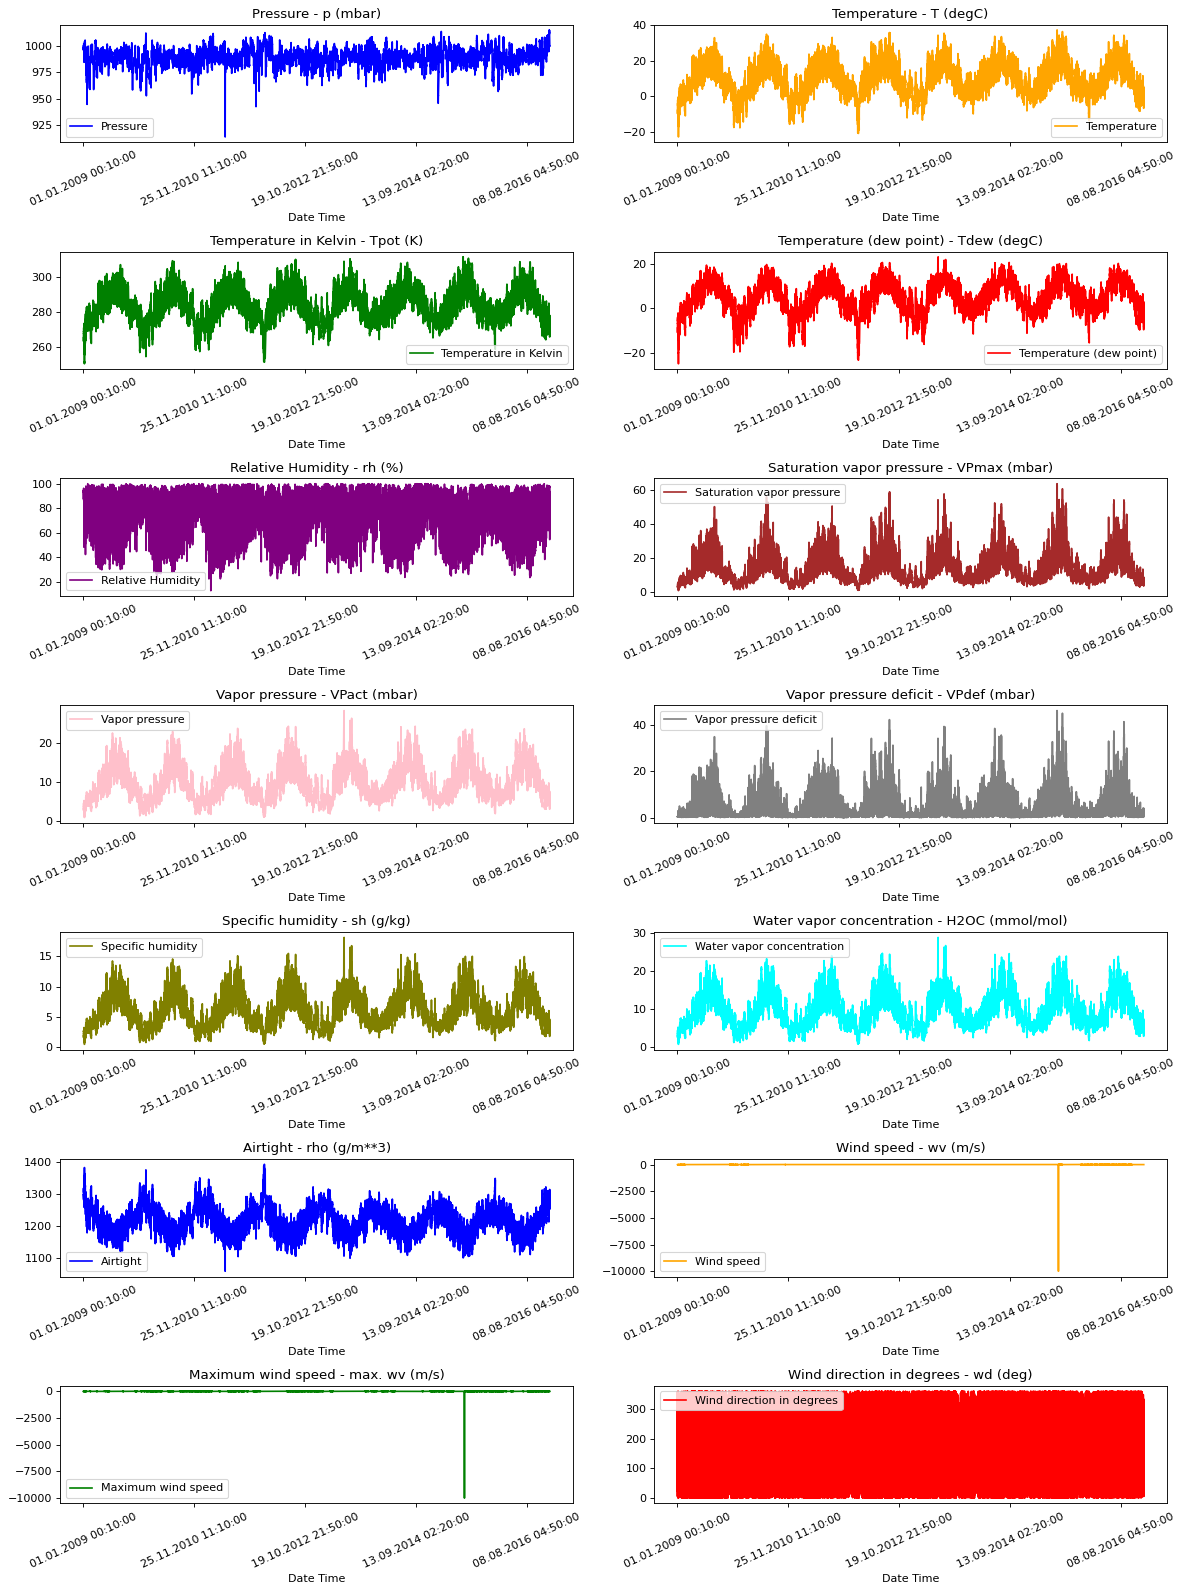

In [ ]:
show_raw_visualization(df)

In [ ]:
# 학습 데이터셋 분할
split_fraction = 0.715
train_split = int(split_fraction * int(df.shape[0]))

In [ ]:
# 하이퍼 파라미터 설정
# 코드 고정
step = 6
past = 720
future = 72
learning_rate = 0.001
batch_size = 256
epochs = 10

In [ ]:
# normalize func 정의
def normalize(data, train_split):
    data_mean = data[:train_split].mean(axis=0)
    data_std = data[:train_split].std(axis=0)
    return (data - data_mean) / data_std

In [ ]:
print(
    "The selected parameters are:",
    ", ".join([titles[i] for i in [0, 1, 5, 7, 8, 10, 11]]),
)

The selected parameters are: Pressure, Temperature, Saturation vapor pressure, Vapor pressure deficit, Specific humidity, Airtight, Wind speed


In [ ]:
# 해당 Title의 열 name 값만 추출
selected_features = [feature_keys[i] for i in [0, 1, 5, 7, 8, 10, 11]]
features = df[selected_features]
features.index = df[date_time_key]
features.head()

,p (mbar),T (degC),VPmax (mbar),VPdef (mbar),sh (g/kg),rho (g/m**3),wv (m/s)
Date Time,,,,,,,
01.01.2009 00:10:00,996.52,-8.02,3.33,0.22,1.94,1307.75,1.03
01.01.2009 00:20:00,996.57,-8.41,3.23,0.21,1.89,1309.80,0.72
01.01.2009 00:30:00,996.53,-8.51,3.21,0.20,1.88,1310.24,0.19
01.01.2009 00:40:00,996.51,-8.31,3.26,0.19,1.92,1309.19,0.34
01.01.2009 00:50:00,996.51,-8.27,3.27,0.19,1.92,1309.00,0.32


In [ ]:
# normalize 수행
features = normalize(features.values, train_split)
features = pd.DataFrame(features)
features.head()

,0,1,2,3,4,5,6
0,0.955451,-2.000020,-1.319782,-0.788479,-1.500927,2.237658,-0.732997
1,0.961528,-2.045185,-1.332806,-0.790561,-1.519521,2.287838,-0.936002
2,0.956666,-2.056766,-1.335410,-0.792642,-1.523239,2.298608,-1.283076
3,0.954236,-2.033604,-1.328898,-0.794724,-1.508364,2.272906,-1.184847
4,0.954236,-2.028972,-1.327596,-0.794724,-1.508364,2.268256,-1.197944


In [ ]:
# 학습, 검증 데이터 분리
train_data = features.loc[0 : train_split - 1]
val_data = features.loc[train_split:]

In [ ]:
start = past + future
end = start + train_split

In [ ]:
# 학습 데이터셋 생성
x_train = train_data[[i for i in range(7)]].values
y_train = features.iloc[start:end][[1]]

In [ ]:
# 시계열 데이터에서 하나의 샘플로 사용할 시간 범위의 길이를 정의
sequence_length = int(past / step)

In [ ]:
#시계열 데이터 생성
dataset_train = keras.preprocessing.timeseries_dataset_from_array(
    # 코드를 작성해주세요
    data=x_train
    ,
    targets=y_train
    ,
    sequence_length=sequence_length,
    sampling_rate=step,
    batch_size=batch_size,
)

In [ ]:
x_end = len(val_data) - past - future

label_start = train_split + past + future

In [ ]:
# 검증 데이터셋 생성
x_val = val_data.iloc[:x_end][[i for i in range(7)]].values
y_val = features.iloc[label_start:][[1]]

In [ ]:
dataset_val = keras.preprocessing.timeseries_dataset_from_array(
    # 코드를 작성해주세요
    data=x_val
    ,
    targets=y_val
    ,
    sequence_length=sequence_length,
    sampling_rate=step,
    batch_size=batch_size,
)

In [ ]:
for batch in dataset_train.take(1):
    inputs, targets = batch

In [ ]:
print("Input shape:", inputs.numpy().shape)
print("Target shape:", targets.numpy().shape)

Input shape: (256, 120, 7)
Target shape: (256, 1)


## **모델 생성**

In [ ]:
inputs = keras.layers.Input(shape=(inputs.shape[1], inputs.shape[2]))
# 코드를 작성해주세요
lstm_out = keras.layers.LSTM(32)(inputs)

outputs = keras.layers.Dense(1)(lstm_out)

In [ ]:
model = keras.Model(inputs=inputs, outputs=outputs)
model.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate), loss="mse")
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 120, 7)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,153 (20.13 KB)

 Trainable params: 5,153 (20.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 모델 가중치 저장 및 Early Stop 적용
path_checkpoint = "model_checkpoint.weights.h5"
es_callback = keras.callbacks.EarlyStopping(monitor="val_loss", min_delta=0, patience=5)

In [ ]:
# callback함수 정의
modelckpt_callback = keras.callbacks.ModelCheckpoint(
    monitor="val_loss",
    filepath=path_checkpoint,
    verbose=1,
    save_weights_only=True,
    save_best_only=True,
)

## **모델 학습**

In [ ]:
history = model.fit(
    dataset_train
    ,
    epochs=epochs,
    validation_data=dataset_val,
    callbacks=[es_callback, modelckpt_callback],
)

Epoch 1/10
1171/1172 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.2672
Epoch 1: val_loss improved from None to 0.14924, saving model to model_checkpoint.weights.h5

Epoch 1: finished saving model to model_checkpoint.weights.h5
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 66s 55ms/step - loss: 0.1826 - val_loss: 0.1492
Epoch 2/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.1467
Epoch 2: val_loss improved from 0.14924 to 0.13724, saving model to model_checkpoint.weights.h5

Epoch 2: finished saving model to model_checkpoint.weights.h5
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 71s 60ms/step - loss: 0.1263 - val_loss: 0.1372
Epoch 3/10
1171/1172 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.1191
Epoch 3: val_loss did not improve from 0.13724
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 66s 57ms/step - loss: 0.1126 - val_loss: 0.1528
Epoch 4/10
1171/1172 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.1168
Epoch 4: val_loss did not improve from 0.13724
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 65s 56ms/step - loss: 0.1096 - val_loss: 0.

## **학습 로스 시각화**

In [ ]:
def visualize_loss(history, title):
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs = range(len(loss))
    plt.figure()
    plt.plot(epochs, loss, "b", label="Training loss")
    plt.plot(epochs, val_loss, "r", label="Validation loss")
    plt.title(title)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

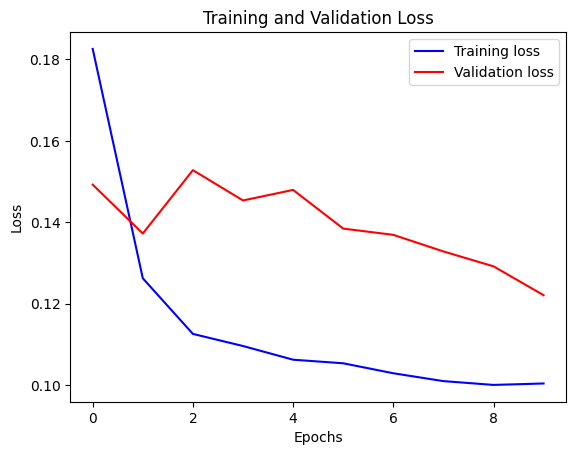

In [ ]:
visualize_loss(history, "Training and Validation Loss")

## **예측 결과 시각화**

In [ ]:
def show_plot(plot_data, delta, title):
    labels = ["History", "True Future", "Model Prediction"]
    marker = [".-", "rx", "go"]
    time_steps = list(range(-(plot_data[0].shape[0]), 0))
    if delta:
        future = delta
    else:
        future = 0

    plt.title(title)
    for i, val in enumerate(plot_data):
        if i:
            plt.plot(future, plot_data[i], marker[i], markersize=10, label=labels[i])
        else:
            plt.plot(time_steps, plot_data[i].flatten(), marker[i], label=labels[i])
    plt.legend()
    plt.xlim([time_steps[0], (future + 5) * 2])
    plt.xlabel("Time-Step")
    plt.show()
    return

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


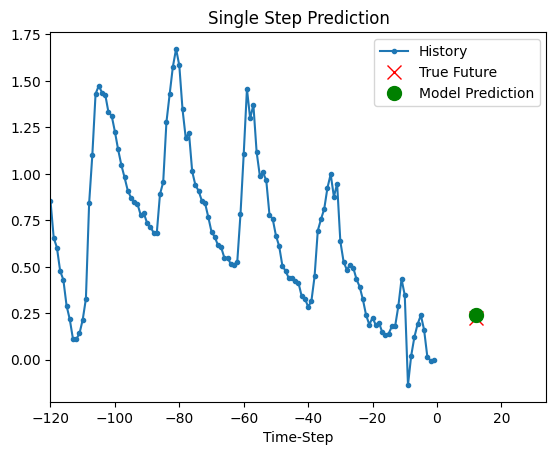

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


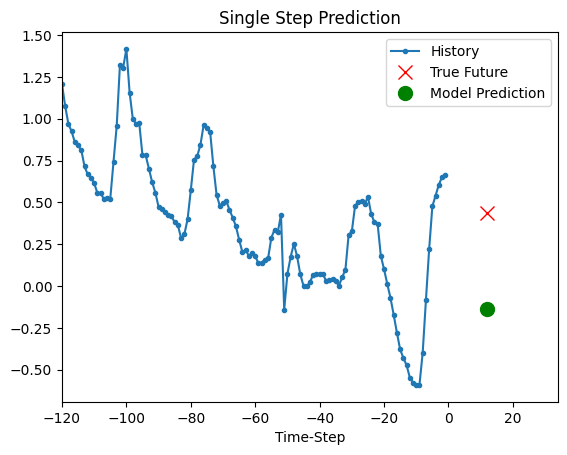

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


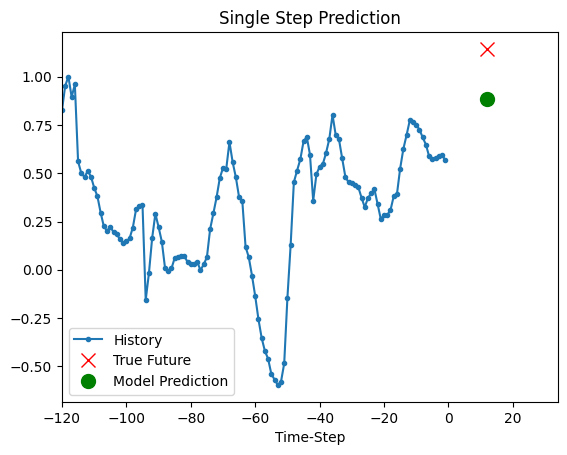

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


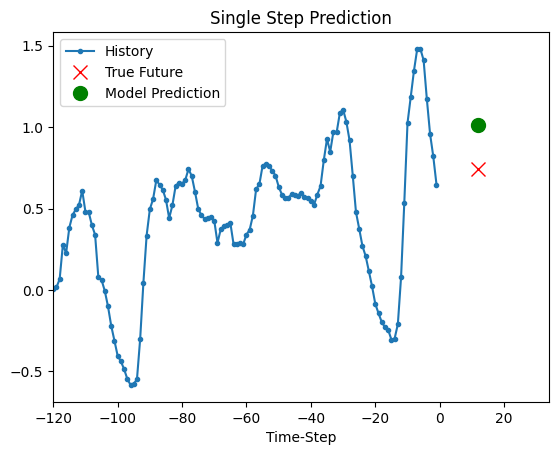

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


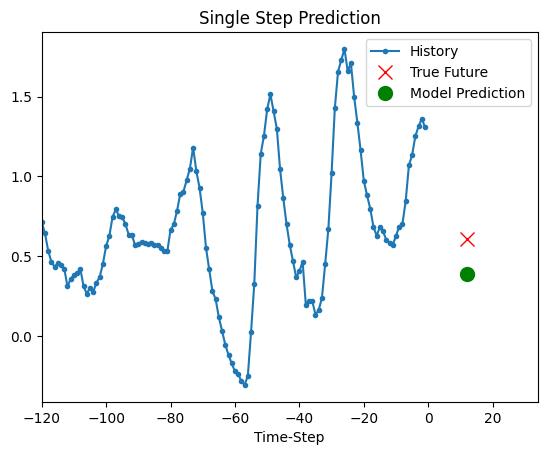

In [ ]:
for x, y in dataset_val.take(5):
    show_plot(
        [x[0][:, 1].numpy(), y[0].numpy(), model.predict(x)[0]],
        12,
        "Single Step Prediction",
    )
